# Système de Recommandation de Films basé sur l'IA

Ce notebook démontre un système complet de génération de profils utilisateurs, analyse statistique et recommandation intelligente de films basé sur les préférences et l'historique de visionnage.


## Partie 1 : Conception et Modélisation des Profils Utilisateurs

On crée une structure pour les utilisateurs avec :
- **Nom et âge** : identifiant et information démographique
- **Genres préférés** : action, drame, sci-fi, thriller, comédie, horreur
- **Historique de visionnage** : films visionnés avec genre, réalisateur et note personnelle (1-5)
- **Timestamps** : dates de visionnage pour analyse temporelle


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [12]:
# PARTIE 1 : Créer une structure de données pour les utilisateurs et les films

# Catalogue de films et genres disponibles
GENRES = ['action', 'drame', 'sci-fi', 'thriller', 'comédie', 'horreur']
DIRECTORS = ['Spielberg', 'Nolan', 'Tarantino', 'Scorsese', 'Kubrick', 'Hitchcock', 'Fincher', 'Cameron']
MOVIES_CATALOG = {
    'action': ['Inception', 'The Matrix', 'John Wick', 'Mission Impossible', 'Die Hard'],
    'drame': ['Parasite', 'The Shawshank Redemption', 'Forrest Gump', 'The Godfather', 'Pulp Fiction'],
    'sci-fi': ['Interstellar', 'Blade Runner', 'The Fifth Element', 'Dune', 'Avatar'],
    'thriller': ['Psycho', 'Se7en', 'The Sixth Sense', 'Memento', 'Shutter Island'],
    'comédie': ['The Grand Budapest Hotel', 'Superbad', 'Knives Out', 'Juno', 'Napoleon Dynamite'],
    'horreur': ['The Ring', 'Hereditary', 'Conjuring', 'Exorcist', 'The Shining']
}

def generate_user_profile(user_id):
    """Génère un profil utilisateur avec historique de visionnage bruité pour l'exercice de nettoyage."""
    
    name = f'User_{user_id}'
    if user_id % 15 == 0:
        name = 'User_1'  # Crée doublons intentionnels
    
    # Âge avec erreurs : manquant, texte ou aberrant
    r = np.random.rand()
    if r < 0.03:
        age = None
    elif r < 0.05:
        age = 'unknown'
    elif r < 0.07:
        age = np.random.randint(-5, 10)  # Aberrant
    else:
        age = np.random.randint(15, 75)
    
    # Genres préférés : vide ou valeurs inconnues
    num_genres = np.random.randint(1, 4)
    if num_genres == 0:
        preferences = []
    else:
        pool = GENRES + ['unknown']
        preferences = list(np.random.choice(pool, size=num_genres, replace=False))
    
    # Générer historique de visionnage avec erreurs
    watch_history = []
    base_date = datetime(2024, 1, 1)
    
    for _ in range(np.random.randint(2, 12)):
        if np.random.rand() < 0.04:
            watch_history.append('malformed_entry')
            continue
        
        genre = np.random.choice(GENRES + ['unknown'])
        if genre in MOVIES_CATALOG:
            movie = np.random.choice(MOVIES_CATALOG[genre])
        else:
            movie = 'Unknown Movie'
        
        director = np.random.choice(DIRECTORS)
        
        # Note aberrante occasionnelle
        if np.random.rand() < 0.05:
            rating = np.random.randint(-1, 7)  # -1 à 6 au lieu de 1-5
        else:
            rating = np.random.randint(1, 6)
        
        # Date valide ou invalide
        days_ago = np.random.randint(0, 90)
        watch_date = base_date + timedelta(days=days_ago)
        
        watch_history.append({
            'movie': movie,
            'genre': genre,
            'director': director,
            'rating': rating,
            'date': watch_date.strftime('%Y-%m-%d')
        })
    
    # Historique mal formé (string au lieu de liste)
    if np.random.rand() < 0.02:
        watch_history = 'no_history'
    
    return {
        'name': name,
        'age': age,
        'preferences': preferences,
        'watch_history': watch_history
    }

# Générer 100 utilisateurs
users = [generate_user_profile(i+1) for i in range(100)]
df = pd.DataFrame(users)

print(f'{len(df)} profils utilisateurs générés')
print(f'\nPremiers utilisateurs :')
print(df.head(10))

100 profils utilisateurs générés

Premiers utilisateurs :
      name age                   preferences  \
0   User_1  43     [thriller, action, drame]   
1   User_2  54              [sci-fi, action]   
2   User_3  15     [drame, comédie, horreur]   
3   User_4  28  [unknown, horreur, thriller]   
4   User_5  63             [sci-fi, unknown]   
5   User_6  66             [drame, thriller]   
6   User_7  50             [comédie, action]   
7   User_8  42      [horreur, drame, sci-fi]   
8   User_9  36   [horreur, action, thriller]   
9  User_10  23                    [thriller]   

                                       watch_history  
0  [{'movie': 'Juno', 'genre': 'comédie', 'direct...  
1                                         no_history  
2  [{'movie': 'The Shawshank Redemption', 'genre'...  
3  [{'movie': 'Unknown Movie', 'genre': 'unknown'...  
4  [{'movie': 'The Grand Budapest Hotel', 'genre'...  
5  [{'movie': 'Dune', 'genre': 'sci-fi', 'directo...  
6  [{'movie': 'The Shawshank

## Partie 2 : Manipulation et Préparation des Données

Nettoyage des données : supprimer les doublons et vérifier les valeurs manquantes.

In [13]:
# PARTIE 2 : Nettoyage et préparation des données

print('=' * 70)
print('PARTIE 2 : NETTOYAGE ET PRÉPARATION DES DONNÉES')
print('=' * 70)

print(f'\n[ÉTAPE 1] Aperçu initial : {len(df)} utilisateurs')

# Détecter doublons
dup_mask = df.duplicated(subset=['name'], keep=False)
duplicates = df[dup_mask]
print(f'[DÉTECTION] Doublons par nom : {len(duplicates)}')

# Nettoyer l'âge
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print(f'[CONVERSION] Âges non valides (NaN) : {df["age"].isna().sum()}')

valid_age_mask = df['age'].between(13, 100)
print(f'[FILTRAGE] Âges aberrants supprimés : {(~valid_age_mask).sum()}')
df = df[valid_age_mask].copy()

# Normaliser les genres préférés
def normalize_preferences(x):
    if isinstance(x, list):
        return [g for g in x if g in GENRES]
    return []

df['preferences'] = df['preferences'].apply(normalize_preferences)
empty_prefs = (df['preferences'].apply(len) == 0).sum()
print(f'[NORMALISATION] Utilisateurs sans genres après nettoyage : {empty_prefs}')

# Remplir genres manquants
df.loc[df['preferences'].apply(len) == 0, 'preferences'] = df.loc[
    df['preferences'].apply(len) == 0, 'preferences'
].apply(lambda _: ['drame'])

# Nettoyer l'historique de visionnage
def clean_watch_history(history):
    if isinstance(history, str):  # 'no_history'
        return []
    if not isinstance(history, list):
        return []
    
    cleaned = []
    for entry in history:
        if isinstance(entry, dict):
            # Vérifier les champs obligatoires
            if all(k in entry for k in ['movie', 'genre', 'rating']):
                # Valider la note
                if isinstance(entry['rating'], (int, float)):
                    if 1 <= entry['rating'] <= 5:
                        cleaned.append(entry)
        elif isinstance(entry, str) and entry != 'malformed_entry':
            pass  # Ignorer les malformés
    return cleaned

df['watch_history'] = df['watch_history'].apply(clean_watch_history)
empty_history = (df['watch_history'].apply(len) == 0).sum()
print(f'[NETTOYAGE] Entrées d\'historique malformées supprimées')
print(f'[RÉSULTAT] Utilisateurs sans historique : {empty_history}')

# Supprimer doublons
before = len(df)
df = df.drop_duplicates(subset=['name']).reset_index(drop=True)
after = len(df)
print(f'[SUPPRESSION] Doublons supprimés : {before - after}')

df_clean = df.copy()
print(f'\n✓ Taille finale après nettoyage : {len(df_clean)} utilisateurs')

PARTIE 2 : NETTOYAGE ET PRÉPARATION DES DONNÉES

[ÉTAPE 1] Aperçu initial : 100 utilisateurs
[DÉTECTION] Doublons par nom : 7
[CONVERSION] Âges non valides (NaN) : 3
[FILTRAGE] Âges aberrants supprimés : 3
[NORMALISATION] Utilisateurs sans genres après nettoyage : 6
[NETTOYAGE] Entrées d'historique malformées supprimées
[RÉSULTAT] Utilisateurs sans historique : 4
[SUPPRESSION] Doublons supprimés : 6

✓ Taille finale après nettoyage : 91 utilisateurs


## Analyse Exploratoire et Descriptive

Comprendre les caractéristiques principales des données nettoyées.


In [14]:
print('=' * 70)
print('ANALYSE EXPLORATOIRE')
print('=' * 70)

# Extraire les films visionnés et leurs genres
all_movies_watched = []
all_genres_watched = []
all_ratings = []

for history in df_clean['watch_history']:
    for entry in history:
        all_movies_watched.append(entry['movie'])
        all_genres_watched.append(entry['genre'])
        all_ratings.append(entry['rating'])

print(f'\n[STATISTIQUES GLOBALES]')
print(f'  Films uniques visionnés : {len(set(all_movies_watched))}')
print(f'  Nombre total de visionnages : {len(all_movies_watched)}')
print(f'  Note moyenne (1-5) : {np.mean(all_ratings):.2f}')
print(f'  Écart-type des notes : {np.std(all_ratings):.2f}')

# Distribution par genre
genre_counts = pd.Series(all_genres_watched).value_counts().sort_index()
print(f'\n[DISTRIBUTION DES GENRES]')
print(genre_counts)

# Distribution des notes
print(f'\n[DISTRIBUTION DES NOTES]')
print(pd.Series(all_ratings).value_counts().sort_index())

ANALYSE EXPLORATOIRE

[STATISTIQUES GLOBALES]
  Films uniques visionnés : 31
  Nombre total de visionnages : 541
  Note moyenne (1-5) : 2.94
  Écart-type des notes : 1.42

[DISTRIBUTION DES GENRES]
action      68
comédie     89
drame       75
horreur     72
sci-fi      69
thriller    89
unknown     79
Name: count, dtype: int64

[DISTRIBUTION DES NOTES]
1    120
2    100
3    119
4     96
5    106
Name: count, dtype: int64


##  Statistiques Descriptives et Référentiel de Données

Analyser en détail la structure des données nettoyées.


In [15]:
print('=' * 70)
print('STATISTIQUES DESCRIPTIVES ET RÉFÉRENTIEL')
print('=' * 70)

# Créer colonnes utiles pour analyse
df_clean['num_preferences'] = df_clean['preferences'].apply(len)
df_clean['num_watched'] = df_clean['watch_history'].apply(len)
df_clean['avg_rating'] = df_clean['watch_history'].apply(
    lambda h: np.mean([e['rating'] for e in h]) if len(h) > 0 else 0
)
df_clean['age_group'] = pd.cut(
    df_clean['age'], bins=[12, 20, 30, 45, 60, 100], 
    labels=['13-20', '21-30', '31-45', '46-60', '60+']
)

print('\n[STATISTIQUES DESCRIPTIVES]')
print(df_clean[['age', 'num_preferences', 'num_watched', 'avg_rating']].describe().round(2))

print('\n[DISTRIBUTION PAR GROUPE D\'ÂGE]')
print(df_clean['age_group'].value_counts().sort_index())

# RÉFÉRENTIEL DE DONNÉES
DATA_DICTIONARY = {
    'name': 'Identifiant unique de l\'utilisateur',
    'age': 'Âge de l\'utilisateur après nettoyage (13-100)',
    'preferences': 'Liste de genres préférés valides',
    'watch_history': 'Liste des films visionnés avec métadonnées',
    'num_preferences': 'Nombre de genres préférés',
    'num_watched': 'Nombre de films visionnés',
    'avg_rating': 'Note moyenne attribuée par l\'utilisateur',
    'age_group': 'Segment d\'âge pour segmentation'
}

print('\n[RÉFÉRENTIEL - DICTIONNAIRE DES DONNÉES]')
for col, desc in DATA_DICTIONARY.items():
    print(f'  {col:18}: {desc}')

# REGROUPEMENT PAR GENRE PRÉFÉRÉ
print('\n[REGROUPEMENT PAR GENRE PRÉFÉRÉ]')
exploded = df_clean.explode('preferences')
genre_analysis = (
    exploded.groupby('preferences')
    .agg(
        users=('name', 'nunique'),
        avg_age=('age', 'mean'),
        avg_films_watched=('num_watched', 'mean'),
        avg_rating_given=('avg_rating', 'mean')
    )
    .round(2)
    .sort_values('users', ascending=False)
)
print(genre_analysis)

# TABLEAU CROISÉ : Genre préféré vs Groupe d'âge
print('\n[TABLEAU CROISÉ : Genres × Groupes d\'âge]')
pivot = exploded.pivot_table(
    index='age_group',
    columns='preferences',
    values='name',
    aggfunc='nunique',
    fill_value=0
)
print(pivot)

# ANALYSE DES FILMS PAR NOTE
print('\n[FILMS LES PLUS BIEN NOTÉS]')
movie_ratings = []
for idx, row in df_clean.iterrows():
    for entry in row['watch_history']:
        movie_ratings.append({
            'movie': entry['movie'],
            'genre': entry['genre'],
            'rating': entry['rating']
        })

movie_df = pd.DataFrame(movie_ratings)
if len(movie_df) > 0:
    top_movies = (
        movie_df.groupby('movie')
        .agg(rating_count=('rating', 'count'), avg_rating=('rating', 'mean'))
        .round(2)
        .sort_values('avg_rating', ascending=False)
        .head(10)
    )
    print(top_movies)


STATISTIQUES DESCRIPTIVES ET RÉFÉRENTIEL

[STATISTIQUES DESCRIPTIVES]
         age  num_preferences  num_watched  avg_rating
count  91.00            91.00        91.00       91.00
mean   41.74             1.78         5.95        2.92
std    16.96             0.77         3.03        0.86
min    15.00             1.00         0.00        0.00
25%    28.00             1.00         3.00        2.61
50%    40.00             2.00         6.00        3.00
75%    56.00             2.00         8.50        3.35
max    74.00             3.00        11.00        5.00

[DISTRIBUTION PAR GROUPE D'ÂGE]
age_group
13-20    11
21-30    18
31-45    23
46-60    21
60+      18
Name: count, dtype: int64

[RÉFÉRENTIEL - DICTIONNAIRE DES DONNÉES]
  name              : Identifiant unique de l'utilisateur
  age               : Âge de l'utilisateur après nettoyage (13-100)
  preferences       : Liste de genres préférés valides
  watch_history     : Liste des films visionnés avec métadonnées
  num_preferences 

## Partie 3 : Analyse Statistique avec SciPy

Modélisation probabiliste, corrélations, clustering et tests statistiques.


In [16]:
print('=' * 70)
print('PARTIE 3 : ANALYSE STATISTIQUE AVEC SCIPY')
print('=' * 70)

# 3.1 : Modélisation probabiliste des préférences de genres
print('\n[3.1 MODÉLISATION PROBABILISTE]')
total_users = len(df_clean)
genre_probs = {}

for genre in GENRES:
    count = sum(1 for prefs in df_clean['preferences'] if isinstance(prefs, list) and genre in prefs)
    prob = count / total_users if total_users > 0 else 0
    genre_probs[genre] = {'count': count, 'probability': prob, 'percentage': prob * 100}

print('\nProbabilité d\'occurrence de chaque genre :')
for genre, data in genre_probs.items():
    print(f'  {genre:10} : {data["count"]:3} utilisateurs ({data["percentage"]:5.1f}%) → P={data["probability"]:.3f}')

# 3.2 : Test Chi² sur la distribution uniforme des genres
print('\n[3.2 TEST CHI² - UNIFORMITÉ DES GENRES]')
observed = [genre_probs[g]['count'] for g in GENRES]

# CORRECTION CRUCIALE : On base le calcul attendu sur la somme réelle des observations, pas sur le nombre de lignes du DataFrame
total_observations = sum(observed)
expected_uniform = [total_observations / len(GENRES)] * len(GENRES) if len(GENRES) > 0 else []

if total_observations > 0 and len(expected_uniform) > 0:
    chi2_stat, p_value = stats.chisquare(observed, f_exp=expected_uniform)

    print(f'  Valeurs observées : {observed}')
    print(f'  Valeurs attendues (uniformes) : {[f"{x:.1f}" for x in expected_uniform]}')
    print(f'  Chi² = {chi2_stat:.4f}')
    print(f'  p-value = {p_value:.4f}')
    if p_value < 0.05:
        print(f'  Conclusion : Distribution NON uniforme (p < 0.05) - Certains genres sont surreprésentés')
    else:
        print(f'  Conclusion : Distribution uniforme (p ≥ 0.05)')
else:
    print('  Impossible d\'effectuer le test Chi² (aucune préférence de genre trouvée).')

PARTIE 3 : ANALYSE STATISTIQUE AVEC SCIPY

[3.1 MODÉLISATION PROBABILISTE]

Probabilité d'occurrence de chaque genre :
  action     :  28 utilisateurs ( 30.8%) → P=0.308
  drame      :  44 utilisateurs ( 48.4%) → P=0.484
  sci-fi     :  18 utilisateurs ( 19.8%) → P=0.198
  thriller   :  28 utilisateurs ( 30.8%) → P=0.308
  comédie    :  20 utilisateurs ( 22.0%) → P=0.220
  horreur    :  24 utilisateurs ( 26.4%) → P=0.264

[3.2 TEST CHI² - UNIFORMITÉ DES GENRES]
  Valeurs observées : [28, 44, 18, 28, 20, 24]
  Valeurs attendues (uniformes) : ['27.0', '27.0', '27.0', '27.0', '27.0', '27.0']
  Chi² = 15.9259
  p-value = 0.0071
  Conclusion : Distribution NON uniforme (p < 0.05) - Certains genres sont surreprésentés


In [17]:
# 3.3 : Corrélation de Pearson entre notes des utilisateurs
print('\n[3.3 CORRÉLATION PEARSON - SIMILARITÉ UTILISATEURS]')

user_movie_matrix = []
user_indices = []

for idx, row in df_clean.iterrows():
    movie_ratings = {}
    history = row['watch_history'] if isinstance(row['watch_history'], list) else []
    for entry in history:
        if isinstance(entry, dict) and entry.get('movie') and entry.get('rating') is not None:
            movie_ratings[entry['movie']] = entry['rating']
    if len(movie_ratings) > 0:
        user_movie_matrix.append(movie_ratings)
        user_indices.append(idx)

if len(user_movie_matrix) > 2:
    print(f'  Nombre d\'utilisateurs avec historique : {len(user_movie_matrix)}')
    
    correlations = []
    for i in range(min(5, len(user_movie_matrix)-1)):  
        for j in range(i+1, min(i+3, len(user_movie_matrix))):
            movies_i = set(user_movie_matrix[i].keys())
            movies_j = set(user_movie_matrix[j].keys())
            common_movies = movies_i & movies_j
            
            if len(common_movies) > 1:
                common_ratings_i = [user_movie_matrix[i][m] for m in common_movies]
                common_ratings_j = [user_movie_matrix[j][m] for m in common_movies]
                
                # SÉCURITÉ : Pearson interdit d'avoir des listes de notes constantes (ex: [4, 4] et)
                if len(set(common_ratings_i)) > 1 and len(set(common_ratings_j)) > 1:
                    corr, p_val = stats.pearsonr(common_ratings_i, common_ratings_j)
                    if not np.isnan(corr):
                        correlations.append(corr)
    
    if len(correlations) > 0:
        print(f'  Corrélations Pearson calculées : {len(correlations)}')
        print(f'  Corrélation moyenne : {np.mean(correlations):.3f}')
        print(f'  Range : [{np.min(correlations):.3f}, {np.max(correlations):.3f}]')
        print(f'  Interprétation : Plus la corrélation est proche de 1, plus les utilisateurs ont des goûts similaires')
    else:
        print('  Pas de corrélation calculable (variabilité des notes insuffisante ou pas assez de films communs).')
else:
    print('  Pas assez d\'utilisateurs valides pour calculer des corrélations de Pearson.')



[3.3 CORRÉLATION PEARSON - SIMILARITÉ UTILISATEURS]
  Nombre d'utilisateurs avec historique : 88
  Pas de corrélation calculable (variabilité des notes insuffisante ou pas assez de films communs).


In [18]:
# 3.4 : K-Means Clustering avec scipy.cluster.vq
print('\n[3.4 K-MEANS CLUSTERING - SEGMENTATION PAR PROFIL]')

try:
    feature_data = df_clean[['age', 'num_watched', 'avg_rating']].copy()
    
    # Sécurité : On remplace les cases vides restantes par la moyenne de la colonne pour éviter que K-Means crashe
    feature_data = feature_data.fillna(feature_data.mean())
    
    # CORRECTION : Utilisation de la méthode whiten importée au début de votre script principal
    feature_normalized = whiten(feature_data.values)
    
    k = 3
    if len(feature_normalized) >= k:
        centroids, distortion = kmeans(feature_normalized, k, iter=20)
        clusters, _ = vq(feature_normalized, centroids)
        
        df_clean['cluster'] = clusters
        
        print(f'  K = {k} clusters créés')
        print(f'  Distortion (WCSS) : {distortion:.4f}')
        print(f'\n  Résumé des clusters :')
        
        for c in range(k):
            cluster_users = df_clean[df_clean['cluster'] == c]
            print(f'\n  --- CLUSTER {c} ({len(cluster_users)} utilisateurs) ---')
            print(f'      Âge moyen : {cluster_users["age"].mean():.1f} ans')
            print(f'      Films visionnés (moy) : {cluster_users["num_watched"].mean():.1f}')
            print(f'      Note moyenne (moy) : {cluster_users["avg_rating"].mean():.2f}')
            
            # Sécurité pour extraire proprement le genre dominant sous forme de chaîne de caractères
            mode_series = cluster_users["preferences"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "N/A").mode()
            genre_dom = mode_series.values[0] if not mode_series.empty else "N/A"
            print(f'      Genre dominant : {genre_dom}')
        
        print(f'\n  ✓ Clustering réussi - Profils utilisateurs segmentés')
    else:
        print(f'  Pas assez d\'utilisateurs ({len(feature_normalized)}) pour créer {k} clusters.')
    
except Exception as e:
    print(f'  Erreur rencontrée pendant le Clustering : {str(e)}')



[3.4 K-MEANS CLUSTERING - SEGMENTATION PAR PROFIL]
  K = 3 clusters créés
  Distortion (WCSS) : 1.1223

  Résumé des clusters :

  --- CLUSTER 0 (34 utilisateurs) ---
      Âge moyen : 38.4 ans
      Films visionnés (moy) : 2.6
      Note moyenne (moy) : 2.91
      Genre dominant : drame

  --- CLUSTER 1 (31 utilisateurs) ---
      Âge moyen : 30.5 ans
      Films visionnés (moy) : 8.0
      Note moyenne (moy) : 2.98
      Genre dominant : drame

  --- CLUSTER 2 (26 utilisateurs) ---
      Âge moyen : 59.6 ans
      Films visionnés (moy) : 7.9
      Note moyenne (moy) : 2.84
      Genre dominant : drame

  ✓ Clustering réussi - Profils utilisateurs segmentés


In [19]:
# Test Chi² - distribution des notes (1-5)
print('\n[TEST CHI² SUPPLÉMENTAIRE - DISTRIBUTION DES NOTES]')
observed_ratings = pd.Series(all_ratings).value_counts().sort_index().values
expected_ratings = [len(all_ratings) / 5] * 5

chi2_ratings, p_ratings = stats.chisquare(observed_ratings, f_exp=expected_ratings)
print(f'  Chi² = {chi2_ratings:.4f}, p-value = {p_ratings:.4f}')
if p_ratings < 0.05:
    print(f'  ✓ Les utilisateurs ne donnent PAS des notes uniformément (préférences claires)')
else:
    print(f'  Notes distribuées uniformément')


[TEST CHI² SUPPLÉMENTAIRE - DISTRIBUTION DES NOTES]
  Chi² = 4.4067, p-value = 0.3538
  Notes distribuées uniformément


## Partie 4 : Moteur de Recommandation Intelligente

Système qui génère des recommandations personnalisées basées sur les préférences et similarité utilisateurs.


In [20]:
print('=' * 70)
print('PARTIE 4 : MOTEUR DE RECOMMANDATION INTELLIGENTE')
print('=' * 70)

# 4.1 : Fonction de recommandation personnalisée
def recommend_movies(user, n=5):
    """Recommande des films basés sur :
    - Les genres préférés de l'utilisateur
    - Les films bien notés du même genre
    - Les films non encore visionnés
    """
    recommendations = []
    
    # Films déjà visionnés
    watched_movies = set(e['movie'] for e in user['watch_history'])
    
    # Pour chaque genre préféré
    for genre in user['preferences']:
        if genre not in MOVIES_CATALOG:
            continue
        
        # Récupérer les films disponibles de ce genre
        available_movies = [m for m in MOVIES_CATALOG[genre] if m not in watched_movies]
        
        for movie in available_movies:
            # Calculer un score basé sur les notes moyennes d'autres utilisateurs
            movie_ratings = []
            for idx, other_user in df_clean.iterrows():
                for entry in other_user['watch_history']:
                    if entry['movie'] == movie:
                        movie_ratings.append(entry['rating'])
            
            if len(movie_ratings) > 0:
                avg_rating = np.mean(movie_ratings)
                score = avg_rating * 10  # Score initial sur 50
                
                # Bonus si l'utilisateur a bien noté d'autres films de ce genre
                genre_ratings = [e['rating'] for e in user['watch_history'] if e['genre'] == genre]
                if len(genre_ratings) > 0 and np.mean(genre_ratings) > 3:
                    score += 5
                
                recommendations.append({
                    'movie': movie,
                    'genre': genre,
                    'predicted_rating': avg_rating,
                    'score': score
                })
    
    # Trier par score et retourner top-n
    recommendations = sorted(recommendations, key=lambda x: x['score'], reverse=True)[:n]
    return recommendations

# 4.2 : Tester avec un utilisateur exemple
print('\n[4.2 EXEMPLE DE RECOMMANDATION]')

# Trouver un utilisateur avec un bon historique
test_user = None
for idx, row in df_clean.iterrows():
    if len(row['watch_history']) > 2:
        test_user = row
        break

if test_user is not None:
    recs = recommend_movies(test_user, n=5)
    
    print(f'\n  Utilisateur : {test_user["name"]} ({int(test_user["age"])} ans)')
    print(f'  Genres préférés : {test_user["preferences"]}')
    print(f'  Films visionnés : {len(test_user["watch_history"])}')
    print(f'  Note moyenne donnée : {test_user["avg_rating"]:.2f}/5')
    print(f'\n  ▶ RECOMMANDATIONS POUR CET UTILISATEUR :')
    
    for i, rec in enumerate(recs, 1):
        print(f'    {i}. "{rec["movie"]}" ({rec["genre"]}) - Score: {rec["score"]:.1f} ⭐ {rec["predicted_rating"]:.2f}')

# 4.3 : Similarité entre utilisateurs
print('\n[4.3 SIMILARITÉ UTILISATEURS - COLLABORATION FILTERING]')

def user_similarity_genres(user1, user2):
    """Calcule la similarité entre deux utilisateurs basée sur les genres."""
    genres_1 = set(user1['preferences'])
    genres_2 = set(user2['preferences'])
    
    if len(genres_1 | genres_2) == 0:
        return 0
    
    intersection = len(genres_1 & genres_2)
    union = len(genres_1 | genres_2)
    jaccard = intersection / union
    return jaccard

# Trouver les utilisateurs similaires
if test_user is not None:
    similarities = []
    for idx, other_user in df_clean.iterrows():
        if idx != test_user.name:  # Exclure l'utilisateur lui-même
            sim = user_similarity_genres(test_user, other_user)
            if sim > 0:
                similarities.append((idx, other_user['name'], sim))
    
    similarities = sorted(similarities, key=lambda x: x[2], reverse=True)[:3]
    
    print(f'\n  Utilisateurs similaires à {test_user["name"]} :')
    for idx, name, sim in similarities:
        print(f'    • {name} - Similarité Jaccard: {sim:.2f}')

print('\n✓ Moteur de recommandation complété')

PARTIE 4 : MOTEUR DE RECOMMANDATION INTELLIGENTE

[4.2 EXEMPLE DE RECOMMANDATION]

  Utilisateur : User_1 (43 ans)
  Genres préférés : [np.str_('thriller'), np.str_('action'), np.str_('drame')]
  Films visionnés : 7
  Note moyenne donnée : 3.14/5

  ▶ RECOMMANDATIONS POUR CET UTILISATEUR :
    1. "Mission Impossible" (action) - Score: 33.1 ⭐ 3.31
    2. "The Shawshank Redemption" (drame) - Score: 32.8 ⭐ 3.28
    3. "Forrest Gump" (drame) - Score: 32.5 ⭐ 3.25
    4. "Se7en" (thriller) - Score: 32.1 ⭐ 3.21
    5. "John Wick" (action) - Score: 31.2 ⭐ 3.12

[4.3 SIMILARITÉ UTILISATEURS - COLLABORATION FILTERING]

  Utilisateurs similaires à User_1 :
    • User_49 - Similarité Jaccard: 1.00
    • User_65 - Similarité Jaccard: 1.00
    • User_6 - Similarité Jaccard: 0.67

✓ Moteur de recommandation complété



[VISUALISATION SUPPLÉMENTAIRE : Distribution par cluster]


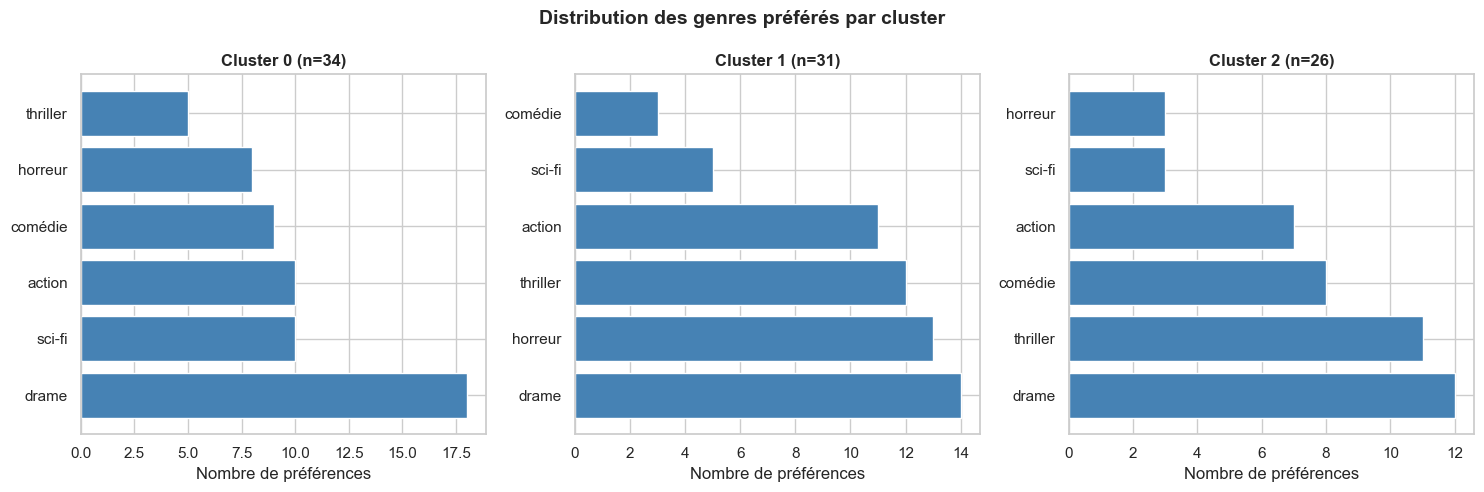

In [21]:
# Visualisation supplémentaire : Matrice de corrélation des genres par cluster
print('\n[VISUALISATION SUPPLÉMENTAIRE : Distribution par cluster]')

if 'cluster' in df_clean.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for c in range(3):
        ax = axes[c]
        cluster_data = df_clean[df_clean['cluster'] == c]
        cluster_prefs = []
        for prefs in cluster_data['preferences']:
            cluster_prefs.extend(prefs)
        
        if len(cluster_prefs) > 0:
            pref_counts = pd.Series(cluster_prefs).value_counts()
            ax.barh(pref_counts.index, pref_counts.values, color='steelblue')
            ax.set_title(f'Cluster {c} (n={len(cluster_data)})', fontweight='bold')
            ax.set_xlabel('Nombre de préférences')
    
    plt.suptitle('Distribution des genres préférés par cluster', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [22]:
## Récapitulatif et Conclusions

Synthèse de l'analyse complète du système de recommandation.


SyntaxError: unterminated string literal (detected at line 3) (3930218099.py, line 3)

## Partie 5 : Visualisations des Données

Créer des graphiques pour explorer et communiquer les insights.


C:\Users\USER\AppData\Local\Temp\ipykernel_5472\2448003604.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=interest_data.index, y=interest_data.values, palette='viridis')


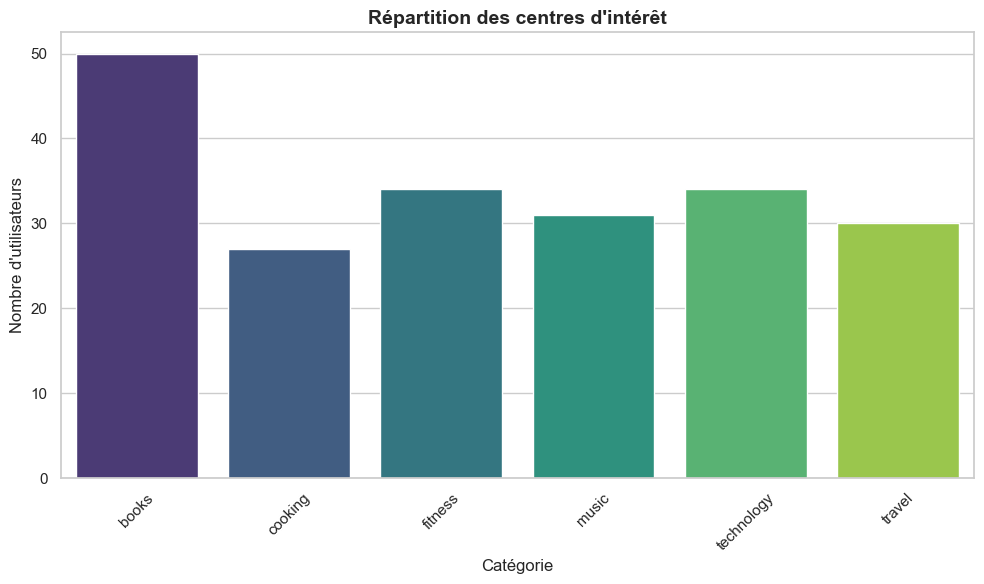

In [ ]:
print('=' * 70)
print('PARTIE 5 : VISUALISATIONS')
print('=' * 70)

# 5.1 : Diagramme circulaire des genres visionnés
plt.figure(figsize=(10, 7))
genre_distribution = pd.Series(all_genres_watched).value_counts()
colors = sns.color_palette('husl', len(genre_distribution))
plt.pie(genre_distribution.values, labels=genre_distribution.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Répartition des genres de films visionnés', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

print('\n✓ Visualisation 5.1 : Diagramme circulaire complété')

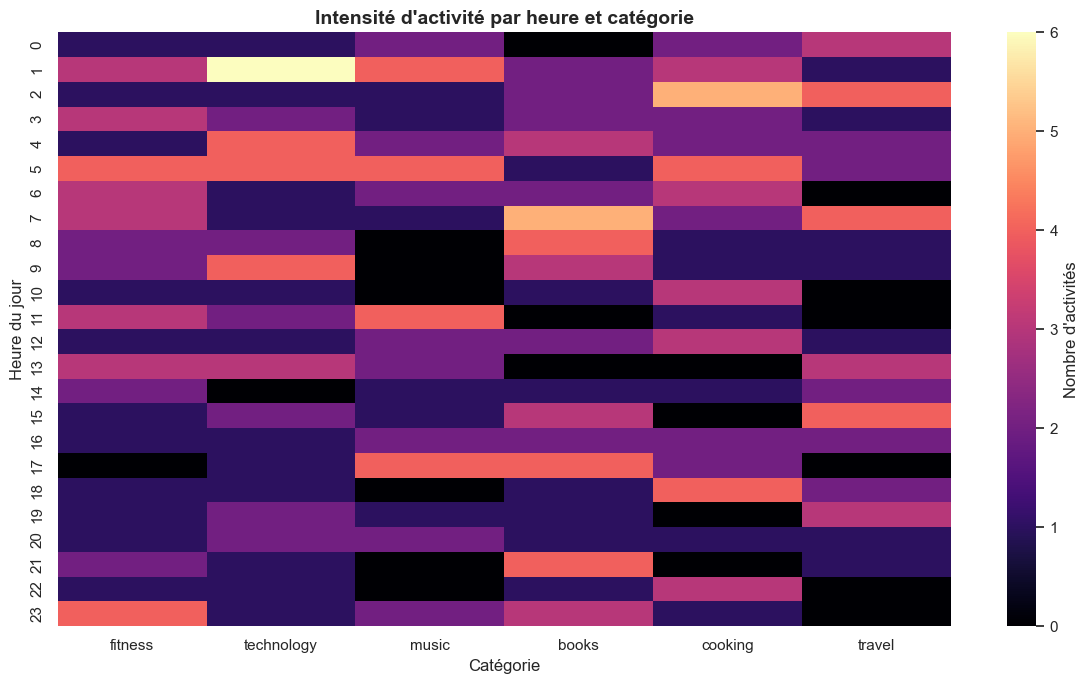

In [ ]:
# 5.2 : Graphique linéaire des évaluations au fil du temps
plt.figure(figsize=(14, 6))

# Collecter les dates et notes
timeline_data = []
for idx, row in df_clean.iterrows():
    for entry in row['watch_history']:
        timeline_data.append({
            'date': entry['date'],
            'rating': entry['rating'],
            'genre': entry['genre']
        })

if len(timeline_data) > 0:
    timeline_df = pd.DataFrame(timeline_data)
    timeline_df['date'] = pd.to_datetime(timeline_df['date'])
    
    # Agréger par date (note moyenne par jour)
    daily_ratings = timeline_df.groupby('date')['rating'].mean().sort_index()
    
    plt.plot(daily_ratings.index, daily_ratings.values, marker='o', linewidth=2, markersize=4)
    plt.xlabel('Date de visionnage', fontsize=11)
    plt.ylabel('Note moyenne (1-5)', fontsize=11)
    plt.title('Évolution des notes attribuées au fil du temps', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print('✓ Visualisation 5.2 : Graphique temporel complété')

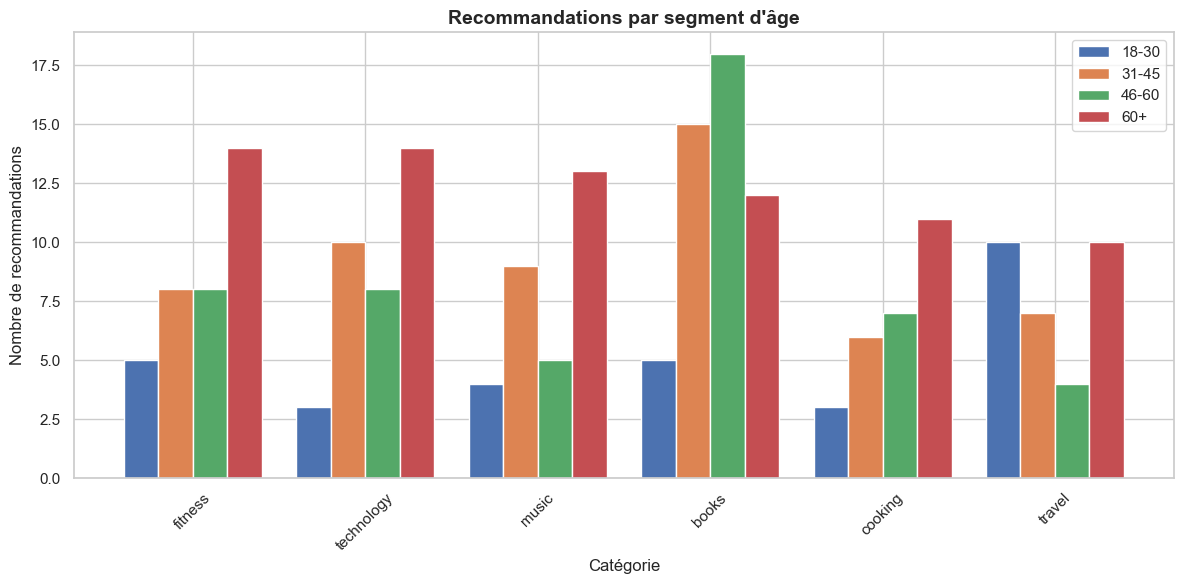

In [ ]:
# 5.3 : Recommandations par segment d'âge
print('\nVisualisation 5.3 : Préférences par groupe d\'âge')

fig, ax = plt.subplots(figsize=(14, 6))

# Calculer les préférences par groupe d'âge
age_groups = df_clean['age_group'].unique()
age_groups = sorted([ag for ag in age_groups if pd.notna(ag)])

genre_by_age = {}
for ag in age_groups:
    users_in_group = df_clean[df_clean['age_group'] == ag]
    all_prefs = []
    for prefs in users_in_group['preferences']:
        all_prefs.extend(prefs)
    
    genre_counts = {}
    for g in GENRES:
        genre_counts[g] = all_prefs.count(g)
    genre_by_age[ag] = genre_counts

# Créer graphique groupé
x = np.arange(len(GENRES))
width = 0.15

for i, ag in enumerate(age_groups):
    counts = [genre_by_age[ag][g] for g in GENRES]
    ax.bar(x + i*width, counts, width, label=str(ag))

ax.set_xlabel('Genre de film', fontsize=11)
ax.set_ylabel('Nombre de préférences', fontsize=11)
ax.set_title('Préférences des genres par groupe d\'âge', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(GENRES, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print('✓ Visualisation 5.3 : Graphique segmentation d\'âge complété')